In [1]:
# Importing the necessary libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [151]:
# Loading the data

titanic_train = pd.read_csv('../input/datasets/laurasdp/titanic-download/train.csv')
titanic_test = pd.read_csv('../input/datasets/laurasdp/titanic-download/test.csv')

# **EDA**

## Understanding the structure of the dataset 

* SibSp: number of siblings/spouses aboard the titanic
* Parch: number of parents/children aboard the titanic
* Fare: price paid for a ticket 
* Embarked: port from which each passenger boarded the titanic (C = Cherbourg, Q = Queenstown, S = Southampton)

### Structure of the data and missing values

In [4]:
# Structure of the dataset

titanic_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_train.shape # There are 891 passengers

(891, 12)

In [5]:
# Basic statistics of the dataset

titanic_train.describe() # Mean: age, fare, sibsp, parch

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Missing values

titanic_train.isna().sum() # NaN that could be relevant: age 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Cardinality of the Cabin variable 

titanic_train['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

There are missing values in the Age and Cabin columns. Handling the missing values for the Age variable will be critical since it is likely to be a parameter that has a great impact on the passengers' survival rate. The Cabin variable has an important cardinality and many of its modalities are rare in the dataset. It is probably not a feature that is key to explain the survival rate on the titanic.

### Distribution of the data

<Axes: xlabel='Age', ylabel='Density'>

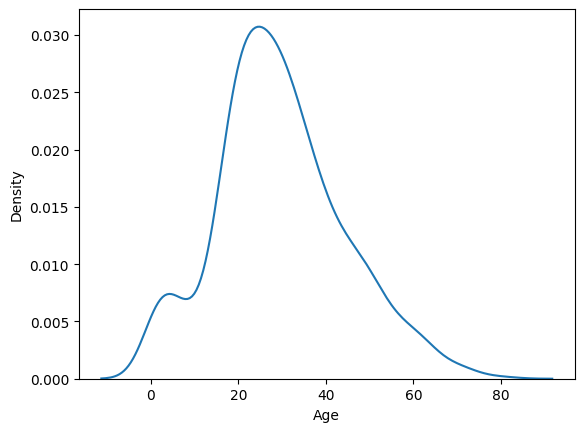

In [7]:
# Age distribution

sns.kdeplot(titanic_train['Age'])

# Passengers are aged 0 to 80 with the majority of them being 20 to 40yo (so mainly young adults and adults)

<Axes: xlabel='Age', ylabel='Density'>

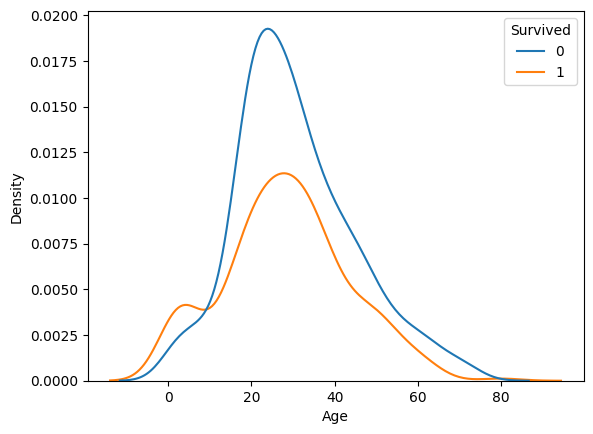

In [8]:
# Survival rate by age group

sns.kdeplot(data=titanic_train, x='Age', hue='Survived')
 
# Survivors tend to be younger, with a higher density between ages 0 and 40 compared to non-survivors.

<Axes: ylabel='Sex'>

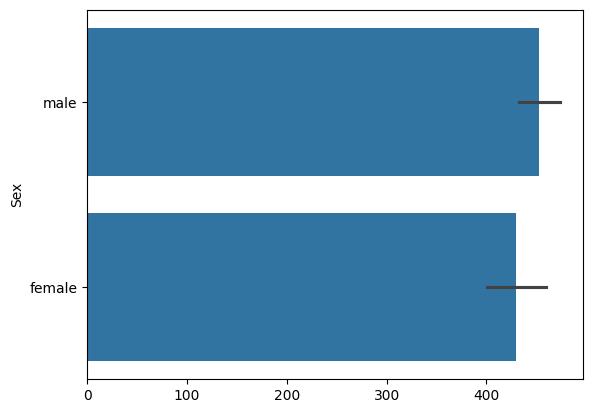

In [9]:
# Sex distribution

sns.barplot(titanic_train['Sex'])

# The distribution of the sex among passengers is homogeneous 

<Axes: xlabel='Fare', ylabel='Density'>

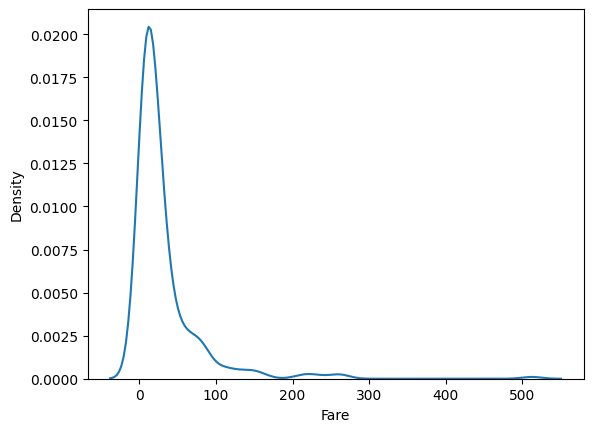

In [10]:
# Fare distribution

sns.kdeplot(titanic_train['Fare'])

# Most passengers paid their boarding ticket between £0 and £50

<Axes: xlabel='Fare', ylabel='Density'>

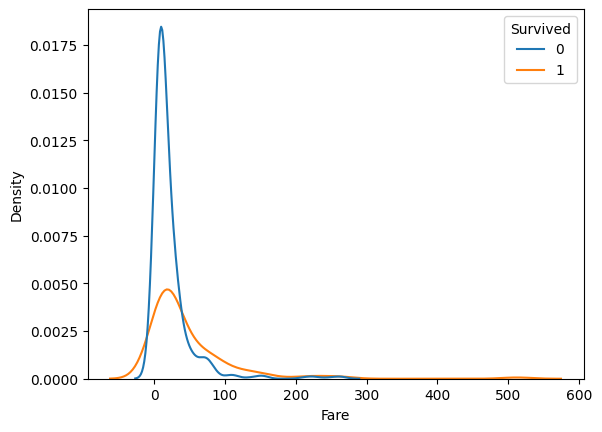

In [11]:
# Survival rate by fare group

sns.kdeplot(data=titanic_train, x='Fare', hue='Survived')

# The majority of the passengers who survived paid their ticket between £0 and £50, corresponding to the range in which most of the data is concentrated. 
# Among the passengers who paid their ticket between £50 and £150, the survival rate is greater than the death rate.
# Thus,£50 seems to be the threshold from which the fare influences the survival rate of the passengers. 

## Relationship between features and survival rate 

In [149]:
# Total survival out of 891 passengers

survived_mask = titanic_train['Survived'] == 1
titanic_train[survived_mask] # 342 passengers out of 891 survived

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age Group,Fare Group
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Age 20-40,Fare 0-75
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Age 20-40,Fare 0-75
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Age 20-40,Fare 0-75
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Age 20-40,Fare 0-75
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Age 0-20,Fare 0-75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,NaN,C,Age 0-20,Fare 0-75
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,Age 40-60,Fare 75-150
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,Age 20-40,Fare 0-75
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Age 0-20,Fare 0-75


<Axes: xlabel='Embarked', ylabel='Survived'>

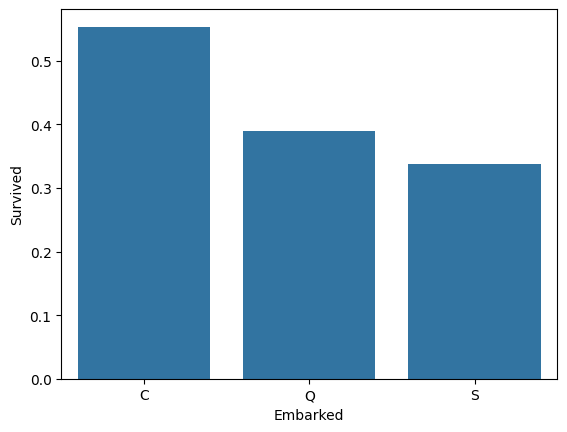

In [152]:
# Relationship Embarked/Survived

titanic_train['Embarked'].unique
# Harbor from which the passengers embarked on the Titanic

# Proportion of passengers that embarked from C, S or Q and survived
embarked_vs_survival = titanic_train.groupby('Embarked')['Survived'].mean()
embarked_vs_survival

# Plotting the result
embarked_vs_survival = embarked_vs_survival.to_frame().reset_index() # transforming the series into a dataframe that is understandable for seaborn
sns.barplot(data=embarked_vs_survival, x='Embarked', y='Survived')

# Survival rates vary by port of embarkation, with passengers embarking from Cherbourg showing higher survival rates.

In [153]:
# Survival by age

# Creating age categories
titanic_train['Age'].min() #0
titanic_train['Age'].max() #80
# 4 age categories: 0-20, 20-40, 40-60, 60-80

titanic_train['Age Group'] = pd.cut(titanic_train['Age'], bins=[0,20,40,60,80],
                                   labels=['Age 0-20', 'Age 20-40', 'Age 40-60', 'Age 60-80'])
titanic_train.head()

# Survival for each age category
survival_age = titanic_train.groupby('Age Group')['Survived'].mean()
survival_age
# Passengers aged 0 to 20 are those who survived the most, followed by those aged 20 to 60
# It is coherent with the previous kdeplot
# (Hypothesis: children and their parents)

/tmp/ipykernel_57/2957393430.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age = titanic_train.groupby('Age Group')['Survived'].mean()


Age Group
Age 0-20     0.458101
Age 20-40    0.397403
Age 40-60    0.390625
Age 60-80    0.227273
Name: Survived, dtype: float64

In [154]:
# Survival by sex

survival_sex = titanic_train.groupby('Sex')['Survived'].mean()
survival_sex

# 74% of women survived while only 18% of men did
# Women survived more than men which makes sense considering the evacuation rules on the titanic
# There is a real effect of sex on the survival rate. It seems to be the most predictive variable of survival

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [155]:
# Survival by class 

survival_class = titanic_train.groupby('Pclass')['Survived'].mean()
survival_class

# Half or more of the passengers of the first and second class survived while only 25% of those from third class did
# Passengers from the first and second class are those who survived the most
# This result makes sense considering the fact that these passengers were the first to be informed of the sinking

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [156]:
# Survival by fare 

titanic_train['Fare'].min() # 0
titanic_train['Fare'].max() # 512.33
titanic_train['Fare'].head()

# Fare categories 
titanic_train['Fare Group'] = pd.cut(titanic_train['Fare'], bins=[0,75,150,225,300,375,450,525],
                                   labels=['Fare 0-75', 'Fare 75-150', 'Fare 150-225', 'Fare 225-300', 'Fare 300-375', 'Fare 375-450', 'Fare 450-525'])
titanic_train.head()

# Survival by fare categories 
survival_fare = titanic_train.groupby('Fare Group')['Survived'].mean()
survival_fare

# The higher the fare, the better the survival rate (but there is a dependance to the way the bins were cut)
# It is coherent with the previous kdeplot where £50 (approximately) appaered to be the ticket price from which we could see a distinct separation
# between survivors and non-survivors 

/tmp/ipykernel_57/1339471842.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_fare = titanic_train.groupby('Fare Group')['Survived'].mean()


Fare Group
Fare 0-75       0.342747
Fare 75-150     0.794118
Fare 150-225    0.642857
Fare 225-300    0.666667
Fare 300-375         NaN
Fare 375-450         NaN
Fare 450-525    1.000000
Name: Survived, dtype: float64

Age, Sex, Class and Fare are four variables that seem to impact the survival rate of the passengers, which is coherent with the evacuation rules on the titanic. Sex seems to be a very predictive feature of the survival. Let us see its impact in regards to its interaction with other interesting features.

In [157]:
# Survival by age + sex combined

survival_age_sex = titanic_train.groupby(['Age Group', 'Sex'])['Survived'].agg(['count', 'sum', 'mean'])
survival_age_sex.columns = ['Number of passengers', 'Survivors', 'Survival rate']
survival_age_sex

# Regardless of the age group, women survived more than men
# There is a dominant effect of the sex, the age being a secondary feature here (sex: THE predictive feature?)

/tmp/ipykernel_57/2018976221.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_age_sex = titanic_train.groupby(['Age Group', 'Sex'])['Survived'].agg(['count', 'sum', 'mean'])


Number of passengers  Survivors  Survival rate
Age Group Sex                                                   
Age 0-20  female                    77         53       0.688312
          male                     102         29       0.284314
Age 20-40 female                   136        107       0.786765
          male                     249         46       0.184739
Age 40-60 female                    45         34       0.755556
          male                      83         16       0.192771
Age 60-80 female                     3          3       1.000000
          male                      19          2       0.105263

In [158]:
# Survival by class + sex combined 

survival_class_sex = titanic_train.groupby(['Pclass', 'Sex'])['Survived'].agg(['count', 'sum', 'mean'])
survival_class_sex.columns = ['Number of passengers', 'Survivors', 'Survival rate']
survival_class_sex

# Regardless of the class, women are the passengers who survived the most 

Number of passengers  Survivors  Survival rate
Pclass Sex                                                   
1      female                    94         91       0.968085
       male                     122         45       0.368852
2      female                    76         70       0.921053
       male                     108         17       0.157407
3      female                   144         72       0.500000
       male                     347         47       0.135447

In [159]:
# Survival by fare group + sex combined 

survival_fare_sex = titanic_train.groupby(['Fare Group', 'Sex'])['Survived'].agg(['count','sum','mean'])
survival_fare_sex.columns = ['Number of passengers', 'Survivors', 'Survival rate']
survival_fare_sex

# The result is the same here 

/tmp/ipykernel_57/3918041556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_fare_sex = titanic_train.groupby(['Fare Group', 'Sex'])['Survived'].agg(['count','sum','mean'])


Number of passengers  Survivors  Survival rate
Fare Group   Sex                                                   
Fare 0-75    female                   252        173       0.686508
             male                     527         94       0.178368
Fare 75-150  female                    43         43       1.000000
             male                      25         11       0.440000
Fare 150-225 female                    10          8       0.800000
             male                       4          1       0.250000
Fare 225-300 female                     8          8       1.000000
             male                       4          0       0.000000
Fare 300-375 female                     0          0            NaN
             male                       0          0            NaN
Fare 375-450 female                     0          0            NaN
             male                       0          0            NaN
Fare 450-525 female                     1          1       1.000000
             male                       2          2       1.000000

In [160]:
# Survival by embark + sex combined

survival_emb_sex = titanic_train.groupby(['Embarked', 'Sex'])['Survived'].agg(['count', 'sum','mean'])
survival_emb_sex.columns =  ['Number of passengers', 'Survivors', 'Survival rate']
survival_emb_sex

# The same goes for when the Sex variable interacts with the Embarked feature

Number of passengers  Survivors  Survival rate
Embarked Sex                                                   
C        female                    73         64       0.876712
         male                      95         29       0.305263
Q        female                    36         27       0.750000
         male                      41          3       0.073171
S        female                   203        140       0.689655
         male                     441         77       0.174603

The age, the class, the fare of the passenger and the port from which they boarded the titanic do impact their survival rate when considered isolated from the reste of the features. However, when the effect of these variables on the survival rate is analyzed through the passenger's sex lens, the Sex variable appears to be a dominant feature to predict their survival on the titanic. 

# **Preprocessing**

## Handling the missing values 

There are NaN in three columns: 
* Age (numerical variable)
* Cabin (categorical variable - probably not an interesting feature)
* Embarked (categorical variable)

The fact that these features are of different types (either numerical or categorical) means the handling of the missing will be different. 

The Cabin variable is linked to the social class of the passengers. We saw how the passengers class impacts the survival rate (when considered isolated from the sex feature) so dropping it from the dataset might not be a good idea.
The same goes for the Embarked variable. 
For the Age, imputing the NaN with the mean seems to be a good strategy but not every passenger has the same average age. 

Since the important features have been identified, let us drop the columns that are not relevant from the dataset.

In [23]:
titanic_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Age Group',
       'Fare Group'],
      dtype='object')

In [161]:
# Dropping the 'Cabin' column and other useless columns

titanic_train['Cabin'].isna().sum()/len(titanic_train)

# 77% of NaN in the 'Cabin' column
# Many data are not usable in this column so dropping it seems a reasonable option

# Dropping the 'Name' and 'Ticket' columns along with the 'Age Group' and 'Fare Group' columns (they were useful for the EDA but not anymore)
drop_titanic_train = titanic_train.drop(['Cabin', 'Name', 'Ticket', 'Age Group', 'Fare Group', 'PassengerId'], axis=1)

### Numerical features

Age is the only numerical feature with missing values. There's no need to preprocess the other numerical features of the dataset. 

In [162]:
from sklearn.impute import SimpleImputer

In [163]:
# Imputing with the median because not all passenger have the same average age

# Creating the imputer 

age_imputer = SimpleImputer(strategy = 'median')
# Fitting the imputer to the age column then replacing the old 'Age' column with the imputed one
drop_titanic_train['Age'] = (age_imputer.fit_transform(drop_titanic_train[['Age']])).ravel()

# Checking the absence of missing values after the imputation step 

drop_titanic_train['Age'].isna().sum()

np.int64(0)

### Categorical features

#### 'Embarked' column

In [164]:
# There are only 2 NaN so I will create an Unknown category in the drop_titanic_train dataset

drop_titanic_train['Embarked'] = drop_titanic_train['Embarked'].fillna('Unknown')
drop_titanic_train['Embarked'].unique()

array(['S', 'C', 'Q', 'Unknown'], dtype=object)

## Encoding categorical variables

In [34]:
drop_titanic_train.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

Categorical variables remaining => encoding:
* Pclass
* Sex
* Embarked

To determine the encoding method, the cardinality of these three columns needs to be checked.

In [165]:
# Cardinality of the Pclass column

print(drop_titanic_train['Pclass'].nunique())
print(drop_titanic_train['Pclass'].dtype)

# It has low cardinality 
# It is not of type object but it is a numerical variable with discrete values. It can be treated as a categorical variable
# It is an ordinal variable so ordinal encoding would be an adequate encoding strategy

3
int64


In [166]:
# Cardinality of the Sex column

drop_titanic_train['Sex'].unique()

# This feature has a low cardinality so one-hot encoding seems appropriate

array(['male', 'female'], dtype=object)

In [167]:
# Cardinality of the Embarked column

drop_titanic_train['Embarked'].unique()

# Same thing here 

array(['S', 'C', 'Q', 'Unknown'], dtype=object)

All three columns have very low cardinality (2 to 3). Pclass is a categorical variable which categories are ordered. So for Sex and Embarked OH encoding will be used.

Ordinal encoding is not useful for Pclass because it's already numerically encoded and ordered. 

### One-hot encoding

In [168]:
from sklearn.preprocessing import OneHotEncoder

In [169]:
# Creating the OH encoder then fitting it to the selected columns

OH_encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(drop_titanic_train[['Sex', 'Embarked']]), index=drop_titanic_train.index)
# Dataframe with the newly encoded columns only

# Putting the names of the columns back (lost with the OH encoding) and joining the encoded dataframe to the original one

OH_cols_train.columns = OH_encoder.get_feature_names_out(['Sex', 'Embarked'])
final_titanic_train = pd.concat([drop_titanic_train, OH_cols_train], axis=1) 

# Dropping the old columns, the ones that are not encoded

final_titanic_train = final_titanic_train.drop(final_titanic_train[['Sex','Embarked']], axis=1) 
final_titanic_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_Unknown
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0,0.0
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0,0.0
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0,0.0
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0,0.0
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0,0.0


# **Model**

## Baseline

Here, a random forest model will be implemented since it is a supervised classification problem involving complex and potentially non linear interactions between features. Moreover, compared to a single decision tree, a random forest model reduces the risk of overfitting and generally generates better predictive performances. 

In [170]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [171]:
# Separating the features from the target

X = final_titanic_train.drop('Survived', axis=1)
y = final_titanic_train['Survived']

In [172]:
# Splitting the dataset into train and validation datasets

X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=2)

print(X_train.shape)
print(X_valid.shape)

(712, 11)
(179, 11)


In [173]:
# Creating the model 

titanic_model = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model.fit(X_train, y_train)

# Validating the model with predictions on the validation dataset

y_pred = titanic_model.predict(X_valid)

# Evaluation of the model => proportion of correct predictions => accuracy score
# Correct metric here: accuracy = number of correct predicitions out of all predictions (based on the true/false positives/negatives matrix)

print(accuracy_score(y_valid, y_pred))

0.8044692737430168


80% of the predictions made by the model are accurate, which is a good score. The model could still be optimized in order to get a better accuracy score. 
List of hyperparameters that could be optimized: 
* n_jobs
* n_estimators
* ccp_alpha
* max_depth
* min_samples_split

Another thing to consider is feature importance: which variables influence survival rate the most?

## Adjusting the model

### Feature importance

The point of feature importance is to access the most influent variables for the model.

In [174]:
# Getting features importance from the model

feature_importances = pd.Series(titanic_model.feature_importances_, X_train.columns).sort_values(ascending=False)
feature_importances

Fare                0.254838
Age                 0.249885
Sex_male            0.158475
Sex_female          0.122432
Pclass              0.080508
SibSp               0.052827
Parch               0.042564
Embarked_S          0.015778
Embarked_C          0.013225
Embarked_Q          0.009402
Embarked_Unknown    0.000068
dtype: float64

Sex is the most important variable to predict the survival of the passengers (29% importance), followed by Fare, Age and Pclass. It is coherent with the EDA. 

Parch, SibSp and Embarked do not seem as important for the model as the other features. We could drop them and check the new accuracy score of the model. 

In [175]:
import matplotlib.pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Fare'),
  Text(1, 0, 'Age'),
  Text(2, 0, 'Sex_male'),
  Text(3, 0, 'Sex_female'),
  Text(4, 0, 'Pclass'),
  Text(5, 0, 'SibSp'),
  Text(6, 0, 'Parch'),
  Text(7, 0, 'Embarked_S'),
  Text(8, 0, 'Embarked_C'),
  Text(9, 0, 'Embarked_Q'),
  Text(10, 0, 'Embarked_Unknown')])

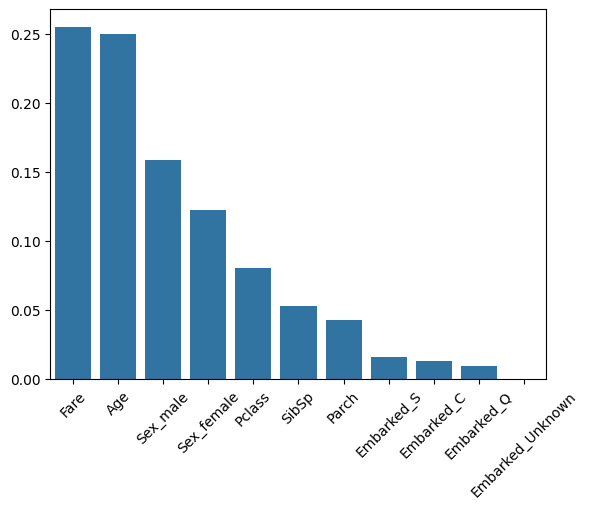

In [176]:
# Plotting features importance

sns.barplot(feature_importances)
plt.xticks(rotation=45)

First let us try and drop Parch from the dataset. 

In [177]:
# Model_1: Dropping Parch

X_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_1_train, X_1_valid, y_1_train, y_1_valid = train_test_split(X_1,y, test_size=0.2, random_state=2)

# Creating the new model

titanic_model_1 = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model_1.fit(X_1_train, y_1_train)

# Validating the model with predictions on the validation dataset

y_pred_1 = titanic_model_1.predict(X_1_valid)

print(accuracy_score(y_1_valid, y_pred_1))

0.8100558659217877


In [178]:
# Model_1_1: Dropping Parch and Embarked

X_1_1 = final_titanic_train.drop(['Survived', 'Parch', 'Embarked_S', 'Embarked_C', 'Embarked_Q'], axis=1)
X_1_1_train, X_1_1_valid, y_1_1_train, y_1_1_valid = train_test_split(X_1_1,y, test_size=0.2, random_state=2)

# Creating the new model

titanic_model_1_1 = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model_1_1.fit(X_1_1_train, y_1_1_train)

# Validating the model with predictions on the validation dataset

y_pred_1_1 = titanic_model_1_1.predict(X_1_1_valid)

print(accuracy_score(y_1_1_valid, y_pred_1_1))

0.8100558659217877


In [179]:
# Model1_2: Dropping Embarked

X_1_2 = final_titanic_train.drop(['Survived', 'Embarked_S', 'Embarked_C', 'Embarked_Q'], axis=1)
X_1_2_train, X_1_2_valid, y_1_2_train, y_1_2_valid = train_test_split(X_1_2,y, test_size=0.2, random_state=2)

# Creating the new model

titanic_model_1_2 = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model_1_2.fit(X_1_2_train, y_1_2_train)

# Validating the model with predictions on the validation dataset

y_pred_1_2 = titanic_model_1_2.predict(X_1_2_valid)

print(accuracy_score(y_1_2_valid, y_pred_1_2))

0.7932960893854749


The accuracy increases when Parch is dropped so it is a good strategy to drop it from the features dataset. **Model no.1 is the best model so far**. However, dropping Embarked along with Parch does not impact the accuracy score of model_1. Plus, dropping Embarked only causes the accuracy to slightly drop compared to the baseline model. Therefore it is not adequate to drop it from the features dataset.

Let us try creating a new feature -  FamilyMembers - that combines Parch and SibSp (these two features are quite redundant) to see if their impact on the prediction of the survival rate is modified. 

In [180]:
# Creating the FamilyMembers feature

final_titanic_train['FamilyMembers'] = final_titanic_train['Parch'] + final_titanic_train['SibSp'] + 1
final_titanic_train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_Unknown,FamilyMembers
0,0,3,22.0,1,0,7.2500,0.0,1.0,0.0,0.0,1.0,0.0,2
1,1,1,38.0,1,0,71.2833,1.0,0.0,1.0,0.0,0.0,0.0,2
2,1,3,26.0,0,0,7.9250,1.0,0.0,0.0,0.0,1.0,0.0,1
3,1,1,35.0,1,0,53.1000,1.0,0.0,0.0,0.0,1.0,0.0,2
4,0,3,35.0,0,0,8.0500,0.0,1.0,0.0,0.0,1.0,0.0,1


In [181]:
# Model_2: Adding the FamilyMembers feature to the baseline model

X_2 = final_titanic_train.drop('Survived', axis=1)
X_2_train, X_2_valid, y_2_train, y_2_valid = train_test_split(X_2,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2 = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model_2.fit(X_2_train, y_2_train)

# Validating the model with predictions on the validation dataset

y_pred_2 = titanic_model_2.predict(X_2_valid)

print(accuracy_score(y_2_valid, y_pred_2))

0.7988826815642458


In [184]:
final_titanic_train.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female',
       'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S',
       'Embarked_Unknown', 'FamilyMembers'],
      dtype='object')

In [192]:
# Model_2_1: Adding the FamilyMembers feature to model_1 (with Parch dropped)

X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=100, random_state=2)

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8156424581005587


In [190]:
X_2_1_train.columns

Index(['Pclass', 'Age', 'SibSp', 'Fare', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_Unknown',
       'FamilyMembers'],
      dtype='object')

Combining Parch and SibSp into one feature causes the accuracy of the baseline model to slightly drop. One explanation is that Random Forests already learn how to combine variables and spot interactions between features. So FamilyMembers does not add to the efficiency of the model because it does not bring any new piece of information.
However, when FamilyMembers is added to the model when Parch is no longer part of the features, then the accuracy of model_1 (that was the best performing one so far) goes from 0.81 to 0.82. Since Parch has been dropped from this feature dataset, FamilyMembers is informative for the model. So **model_2_1** is the most accurate of all the models that were tested. 

Now let us try optimizing the model (model_2_1) by tuning the hyperparameters. 

### Model optimization

Key parameters to adjust:
* n_estimators = number of trees
* **max_depth (no.1 parameter to optimize)** = max number of leaves from the root to the farthest leaf (if a tree is too deep, then the number of samples in one leaf is so low that the risk of overfitting increases)
* min_samples_split = min number of samples to split an internal node
* min_samples_leaf = min number of samples in a leaf/to be at a leaf node

They will be adjusted one by one to get a good understanding of the impact of their modification on the model. 

#### max_depth

With model_2_1 (Parch dropped and FamilyMembers feature added)

In [193]:
X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=100, random_state=2, max_depth=13)

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8268156424581006


#### min_samples_leaf

Minimal number of observations in a leaf

In [194]:
X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=100, random_state=2, 
                                           max_depth=13, min_samples_leaf=1)

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8268156424581006


#### min_samples_split

Minimal number of observations to split a leaf

In [195]:
X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=100, random_state=2, 
                                           max_depth=13, min_samples_leaf=1,
                                          min_samples_split=3)

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8268156424581006


#### n_estimators

In [196]:
X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=150, random_state=2, 
                                           max_depth=13, min_samples_leaf=1,
                                          min_samples_split=3)

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8324022346368715


This model is the best performing one.

Other parameter to test now: 
* max_features = number of features used for each split (test sqrt, log2, None) => reducing the number of features per split could improve the model

In [198]:
X_2_1 = final_titanic_train.drop(['Survived', 'Parch'], axis=1)
X_2_1_train, X_2_1_valid, y_2_1_train, y_2_1_valid = train_test_split(X_2_1,y, test_size=0.2, random_state=2)

# Creating the new model 

titanic_model_2_1 = RandomForestClassifier(n_estimators=150, random_state=2, 
                                           max_depth=13, min_samples_leaf=1,
                                          min_samples_split=3, #max_features=3
                                          )

# Training the model on the training dataset

titanic_model_2_1.fit(X_2_1_train, y_2_1_train)

# Validating the model with predictions on the validation dataset

y_pred_2_1 = titanic_model_2_1.predict(X_2_1_valid)

print(accuracy_score(y_2_1_valid, y_pred_2_1))

0.8324022346368715


Tuning the max_features hyperparameter does not improve nor worsen the model. Thus, this hyperparametrer has no impact on the model in this context and at this optimization stage.

Let us make a more advanced analysis of the accuracy of the model (because the accuracy score is limited).

In [199]:
# Confusion matrix for model_2_1
# True positives/negatives and false positives/negatives

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_2_1_valid, y_pred_2_1))

[[90 10]
 [20 59]]


There are 90% of true negatives (predicted dead and really dead) and 59% of true positives (predicted surviving and really survived). 
The model is better at predicting death than survival. 
Precision and recall metrics are more accurate and nuanced than accuracy alone. Precision describes how trustworthy the positive predicitions are. Recall measures how well the model captured the actual positive cases (DataCamp). 
* Precision = TP/(TP/FP) = 59/(59+10) = 0.75
  The precision is good. A few false
  survivors.
  "Survived"predictions are mostly accurate.
* Recall = TP/(TP+FN) = 0.85
  There are 85% of true positives (of actual
  survivors).
  But there are still survivors that are missed
  by the model.

The confusion matrix, along with the accuracy score of model_2_1, shows that the model is pretty accurate. It is better at predicting death than survival.

# **Pipeline**

What the pipeline must contain:
* preprocessing:
  * drop of the columns
  * imputation for the Age column
  * fill NaN Embarked
  * encoding of the variables
* model: optimized RF 

## Creating the pipeline

In [200]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [201]:
# Numerical columns and categorical columns

num_cols = ['Age', 'Fare', 'SibSp', 'Pclass', 'FamilyMembers']
cat_cols = ['Sex', 'Embarked']

# Preprocessing the columns with the right transformations

## Numerical columns: imputation with the median
num_transformer = SimpleImputer(strategy='median')

## Categorical columns: imputation & OH encoding
## The pipeline allows us to combine two steps: filling NaN values and encoding
cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combining all the transformations together with the ColumnTransformer

# ColumnTransformer helps us putting together all the transformations defined above and says: "for these columns, apply these transformations"
# Structure: (name, transformation, columns)
preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Final pipeline

# Putting the transformed columns into the model: transforming the data then training the model
model = RandomForestClassifier(n_estimators=150,
                              max_depth=13,
                              min_samples_split=3,
                              min_samples_leaf=1,
                              random_state=2)

pipeline = Pipeline(steps = [
    ('preprocessing', preprocessor),
    ('model', model)
])

## Validation of the model

In [203]:
titanic_train['FamilyMembers'] = titanic_train['Parch'] + titanic_train['SibSp'] + 1
X = titanic_train.drop(['Survived', 'Cabin', 'Parch', 'Name', 'Ticket','Age Group', 'Fare Group', 'PassengerId'], axis=1)
y = titanic_train['Survived']

X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=0.2, random_state=2)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)

print(accuracy_score(y_valid, y_pred))

0.8212290502793296


## Fitting the model on the whole train dataset

In [204]:
pipeline.fit(X,y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Pclass', 'FamilyMembers']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked'])])),
                ('model',
                 RandomForestClassifier(max_depth=13, min_samples_split=3,
                                        n_estimators=150, random_state=2))])

## Predictions on the test dataset

In [210]:
titanic_test['FamilyMembers'] = titanic_test['Parch'] + titanic_test['SibSp'] + 1
X_test = titanic_test.drop(['Cabin', 'Name', 'Ticket', 'Parch', 'PassengerId'], axis=1)

predictions = pipeline.predict(X_test)

In [206]:
print(X.columns)
print(X_test.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked', 'FamilyMembers'], dtype='object')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked', 'FamilyMembers'], dtype='object')


# **Submission**

In [211]:
my_submission = pd.DataFrame({'PassengerId' : titanic_test['PassengerId'], 'Survived': predictions})
my_submission.to_csv('submission_titanic_v2.csv', index=False)